# ML - REGRESION LOGISTICA

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle

## Paso 1: Definicion del problema (target)

Predecir si un cliente contratará o no un depósito a largo plazo, la tenemos localizada en la variable 'y'

## Paso 2: Recopilación de datos 
 
[Fuente](https://raw.githubusercontent.com/4GeeksAcademy/logistic-regression-project-tutorial/main/bank-marketing-campaign-data.csv)

|  Variable   |                   Definition                    |          
|:-----------:|:-----------------------------------------------:|
| age | Edad del cliente (numérico) |
| job | Tipo de trabajo (categórico)|
| marital | Estado civil (categórico) |
| education | Nivel de educación (categórico)|
| default | ¿Tiene crédito actualmente? (categórico) |
| housing | ¿Tiene un préstamo de vivienda? (categórico) |
| loan |  ¿Tiene un préstamo personal? (categórico) |
| contact | Tipo de comunicación de contacto (categórico) |
| month |  Último mes en el que se le ha contactado (categórico) |
| day_of_week | Último día en el que se le ha contactado (categórico) |
| duration |  Duración del contacto previo en segundos (numérico) |
| campaign |  Número de contactos realizados durante esta campaña al cliente (numérico) |
| pdays |  Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico) |
| previous | Número de contactos realizados durante la campaña anterior al cliente (numérico)|
| poutcome | Resultado de la campaña de marketing anterior (categórico)|
| emp.var.rate |Tasa de variación del empleo. Indicador trimestral (numérico)|
| cons.price.idx | Índice de confianza del consumidor. Indicador mensual (numérico)|
| cons.conf.idx | Índice de precios al consumidor. Indicador mensual (numérico)|
| euribor3m | Tasa EURIBOR 3 meses. Indicador diario (numérico)|
| nr.employed | Número de empleados. Indicador trimestral (numérico)|
| y | TARGET. El cliente contrata un depósito a largo plazo o no (categórico)|

### Importamos los datos y creamos el DataFrame

In [3]:
df = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv', sep=';') ##apuntar al directorio local, no al de internet
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Paso 2: Realizamos un EDA completo


### Analisis descriptivo

In [4]:
# Obtenemos las dimensiones
df.shape

(41188, 21)

In [5]:
# Obtenemos informacion sobre el tipo de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Obtenemos información estadística de las variables numércias
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


> ## Observaciones:
>
> - Existen un total de 41188 filas (en este caso, clientes) y 21 columnas, entre las cuales está el target a predecir, 'y'
> - Todas las columnas cuentan siempre con valor, no tienen valores nulos.
> - Los datos constan de 10 variables numércias y 11 categóricas

### Limpieza de datos

In [7]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


> ## Conclusiones:
>
> - Analizando los 12 registros que detecta como duplicados, decidimos que no lo son por lo que no los vamos a eliminar
> - En un principio todas las variables no pueden aportan información significativa para el analisis, por lo que no vamos a eliminar ninguna.

### Análisis de Variables

#### Análisis de Variables Univariantes Categóricas

In [8]:
df[df['default'] == 'unknown']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
15,54,retired,married,basic.9y,unknown,yes,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40886,70,retired,married,basic.4y,unknown,no,no,cellular,oct,thu,...,1,14,3,failure,-1.1,94.601,-49.5,0.965,4963.6,no
40940,49,admin.,married,high.school,unknown,no,no,cellular,oct,wed,...,1,6,3,success,-1.1,94.601,-49.5,0.985,4963.6,yes
40941,66,retired,married,basic.4y,unknown,unknown,unknown,cellular,oct,wed,...,1,6,3,success,-1.1,94.601,-49.5,0.985,4963.6,yes
40969,84,retired,divorced,basic.4y,unknown,yes,no,cellular,oct,fri,...,4,999,0,nonexistent,-1.1,94.601,-49.5,0.993,4963.6,no


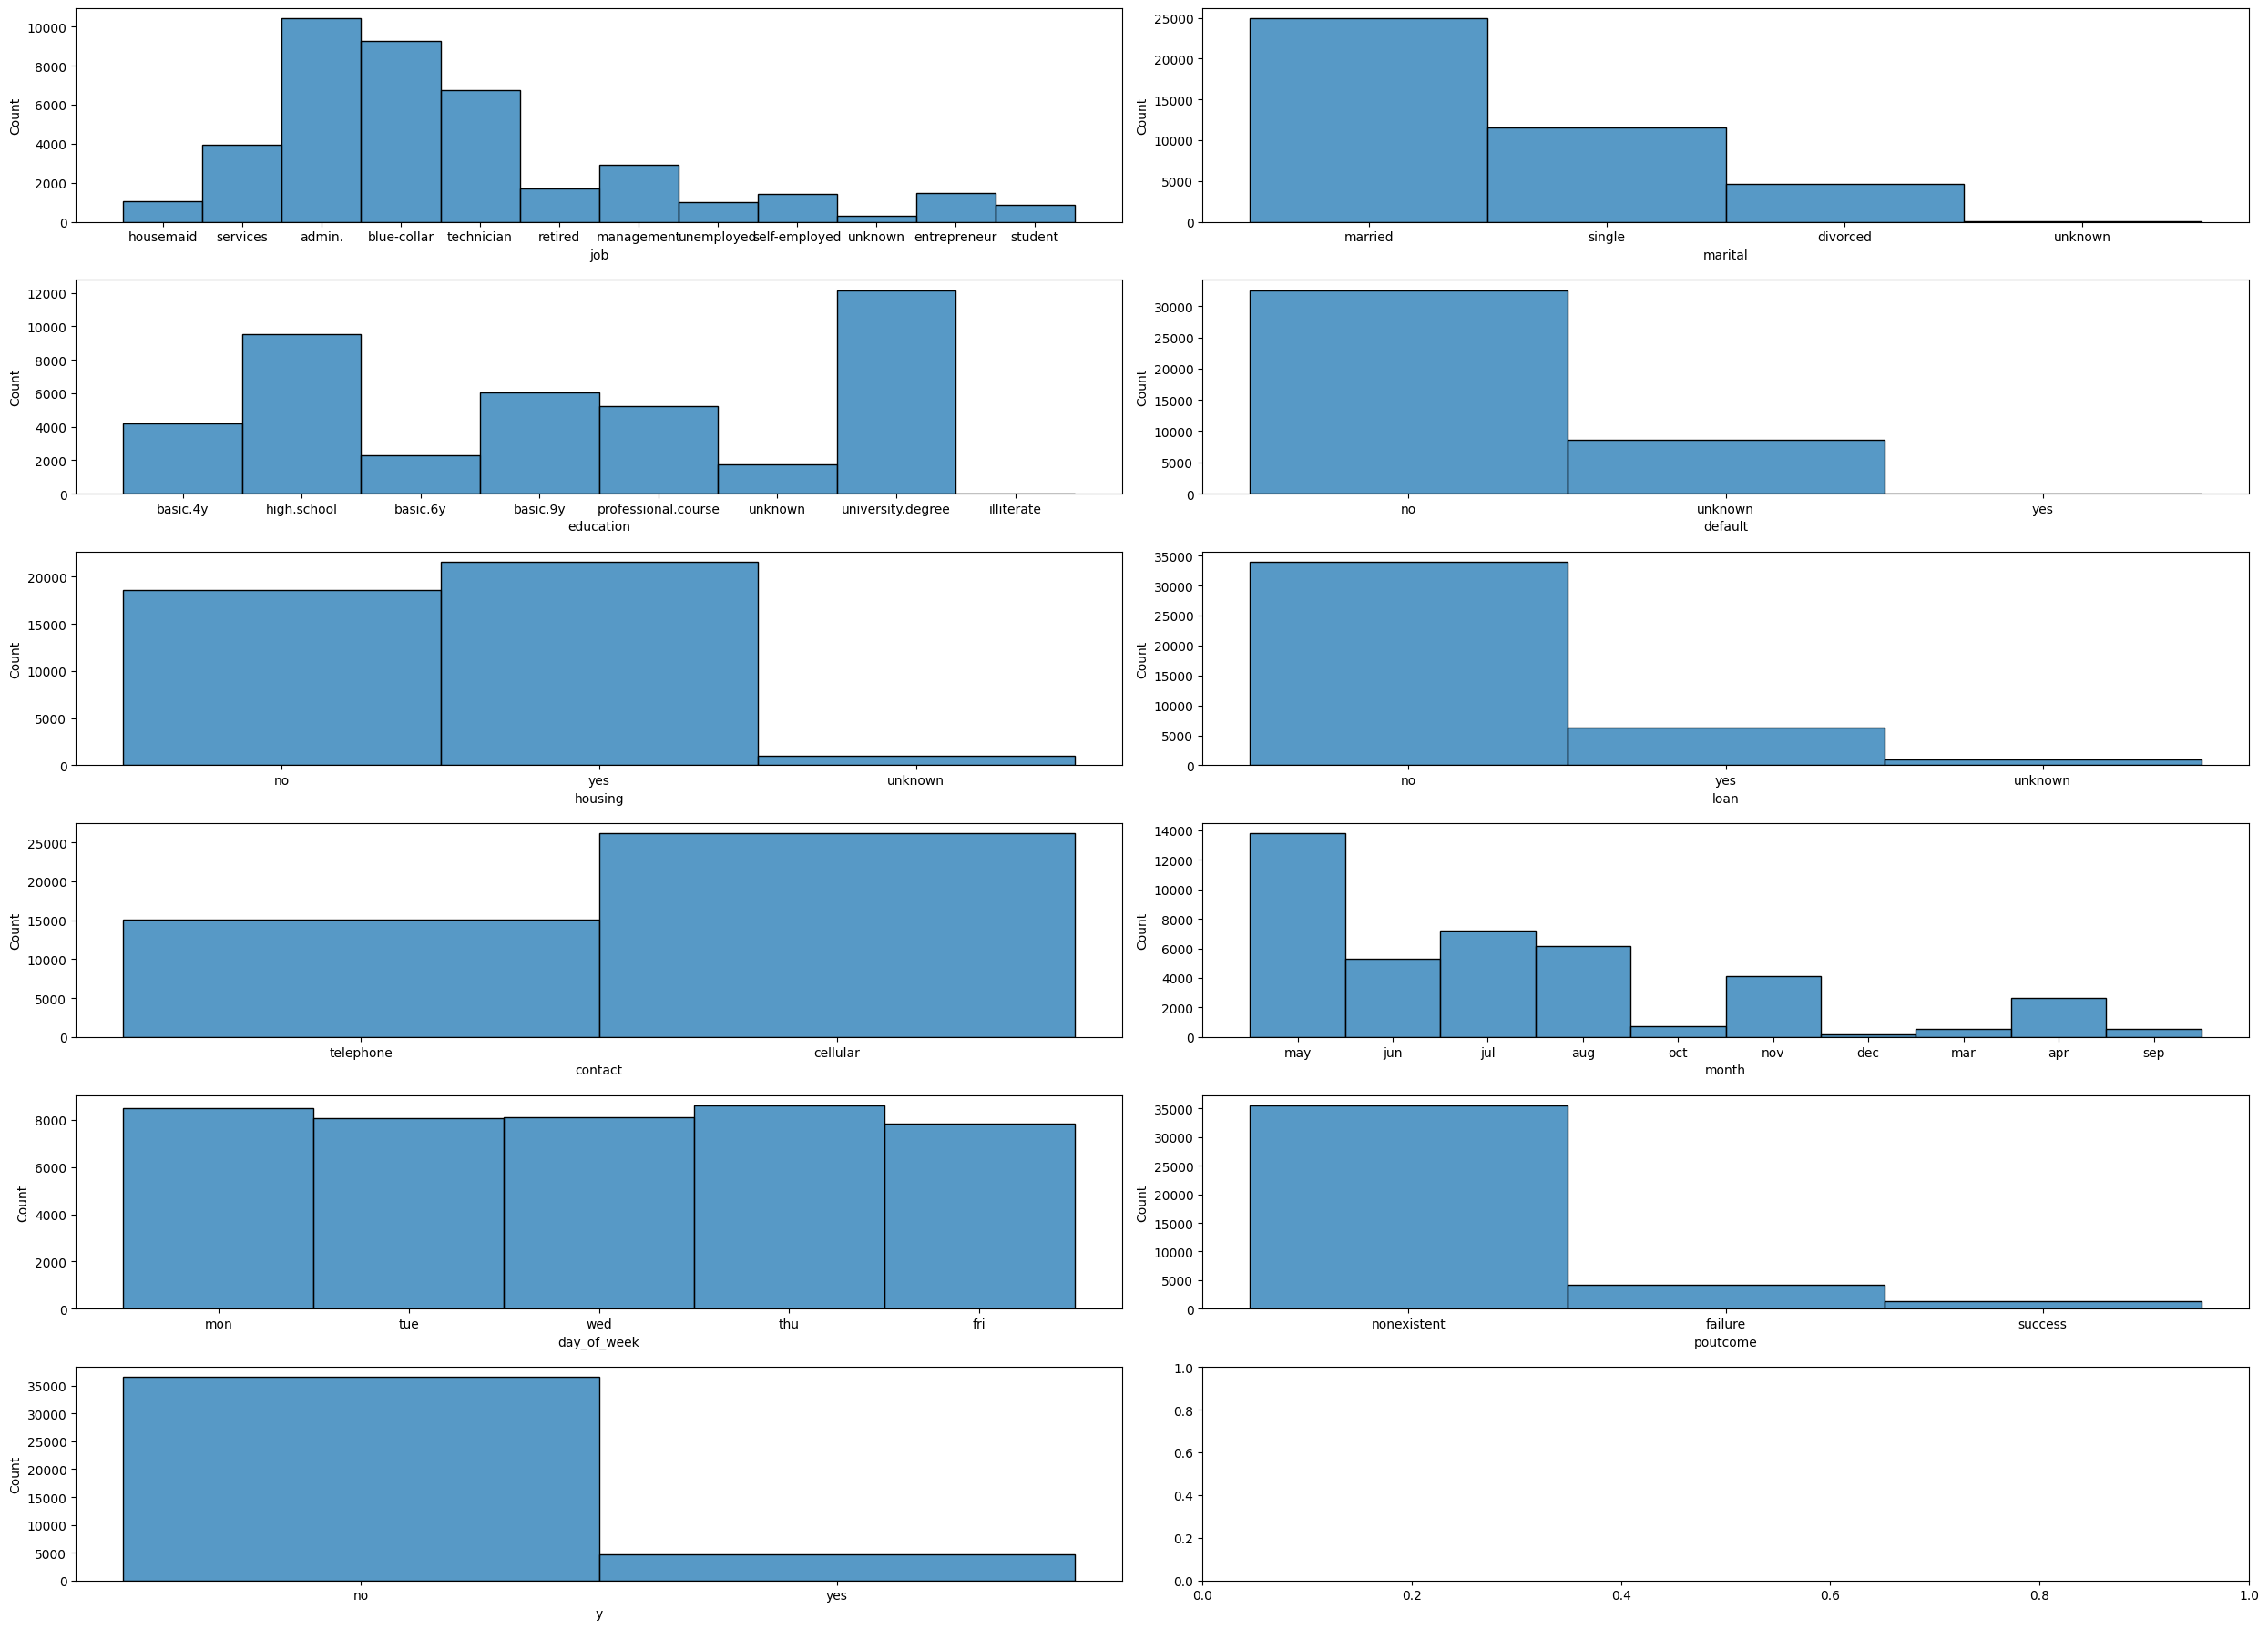

In [9]:
fig, axis = plt.subplots(6, 2, figsize=(25,18))

sns.histplot(ax=axis[0, 0], data=df, x='job')
sns.histplot(ax=axis[0, 1], data=df, x='marital')
sns.histplot(ax=axis[1, 0], data=df, x='education')
sns.histplot(ax=axis[1, 1], data=df, x='default')
sns.histplot(ax=axis[2, 0], data=df, x='housing')
sns.histplot(ax=axis[2, 1], data=df, x='loan')
sns.histplot(ax=axis[3, 0], data=df, x='contact')
sns.histplot(ax=axis[3, 1], data=df, x='month')
sns.histplot(ax=axis[4, 0], data=df, x='day_of_week')
sns.histplot(ax=axis[4, 1], data=df, x='poutcome')
sns.histplot(ax=axis[5, 0], data=df, x='y')

plt.tight_layout()

> ## Observaciones
>
> - En la mayoria de variables tenemos datos desconocidos (unknown, nonexistent)
> - Sobre el target, 4640 clientes (11%) contratarán un deposito a largo plazo

#### Análisis de Variables Univariantes Numéricas

In [10]:
df[df['pdays'] == 999]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


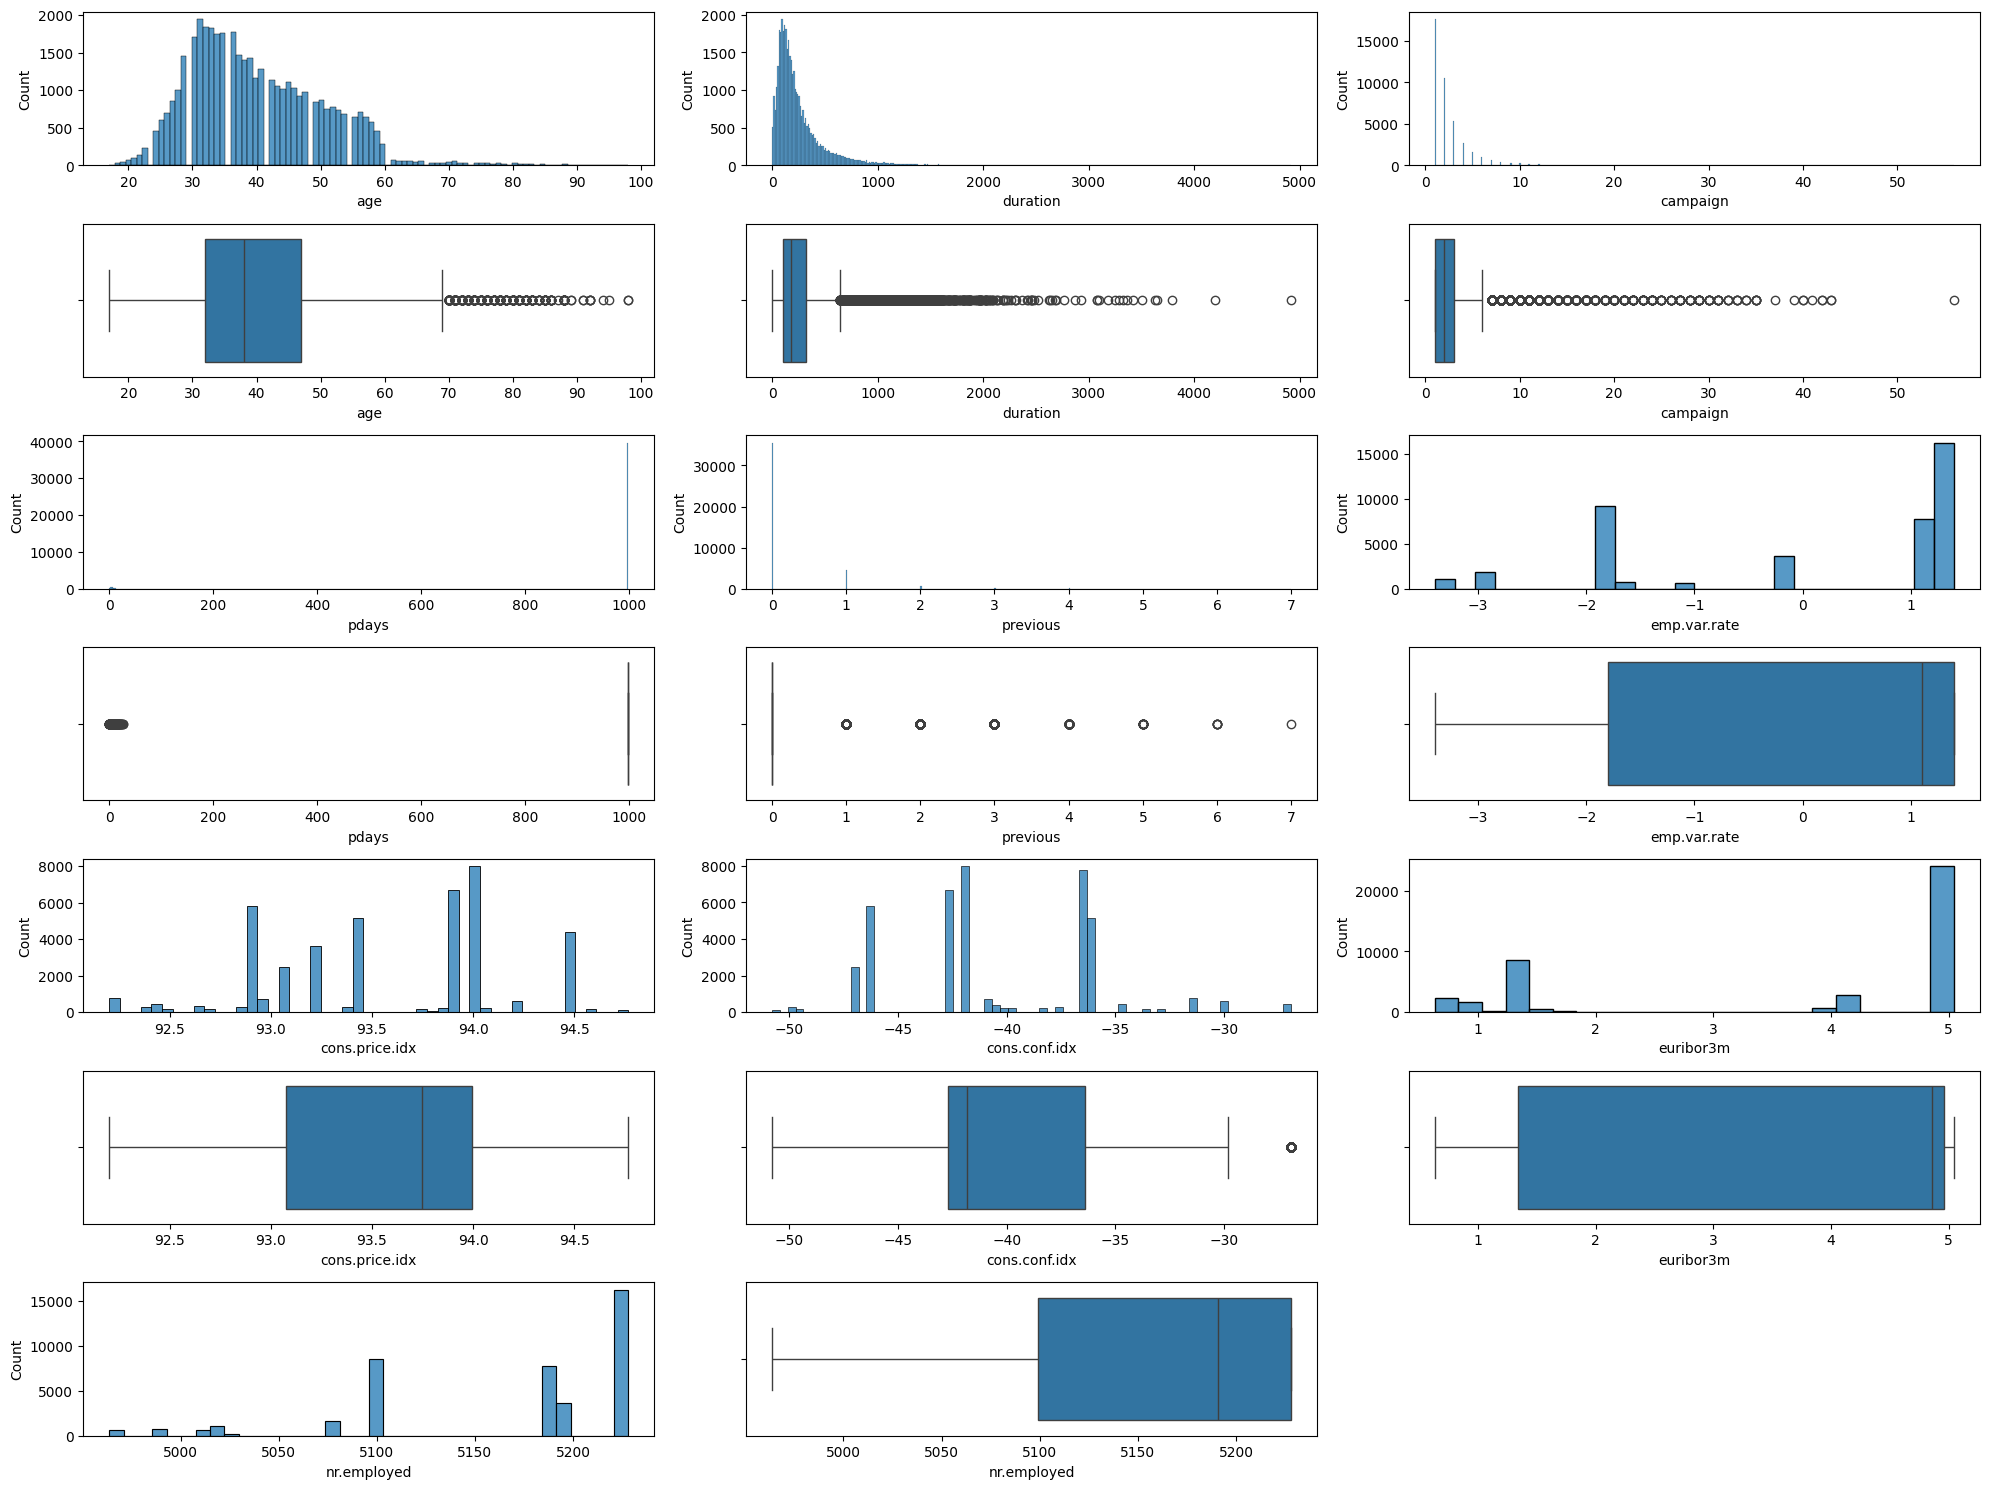

In [11]:
fig, axis = plt.subplots(7, 3, figsize=(20,15))

sns.histplot(ax=axis[0, 0], data=df, x='age')
sns.boxplot(ax=axis[1, 0], data=df, x='age')
sns.histplot(ax=axis[0, 1], data=df, x='duration')
sns.boxplot(ax=axis[1, 1], data=df, x='duration')
sns.histplot(ax=axis[0, 2], data=df, x='campaign')
sns.boxplot(ax=axis[1, 2], data=df, x='campaign')
sns.histplot(ax=axis[2, 0], data=df, x='pdays')
sns.boxplot(ax=axis[3, 0], data=df, x='pdays')
sns.histplot(ax=axis[2, 1], data=df, x='previous')
sns.boxplot(ax=axis[3, 1], data=df, x='previous')
sns.histplot(ax=axis[2, 2], data=df, x='emp.var.rate')
sns.boxplot(ax=axis[3, 2], data=df, x='emp.var.rate')
sns.histplot(ax=axis[4, 0], data=df, x='cons.price.idx')
sns.boxplot(ax=axis[5, 0], data=df, x='cons.price.idx')
sns.histplot(ax=axis[4, 1], data=df, x='cons.conf.idx')
sns.boxplot(ax=axis[5, 1], data=df, x='cons.conf.idx')
sns.histplot(ax=axis[4, 2], data=df, x='euribor3m')
sns.boxplot(ax=axis[5, 2], data=df, x='euribor3m')
sns.histplot(ax=axis[6, 0], data=df, x='nr.employed')
sns.boxplot(ax=axis[6, 1], data=df, x='nr.employed')

fig.delaxes(ax=axis[6, 2])
plt.tight_layout()

### Análisis de Variables Multivariante (numerico-numerico)

    y - (age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed)

In [12]:
# Convertimos el target 'y' a numerico y lo guardamos en una nueva variable 'y_n' para poder comparar con resto de variables numéricas
df['y_n'] = df['y'].apply(lambda x:1 if x == 'yes' else 0)

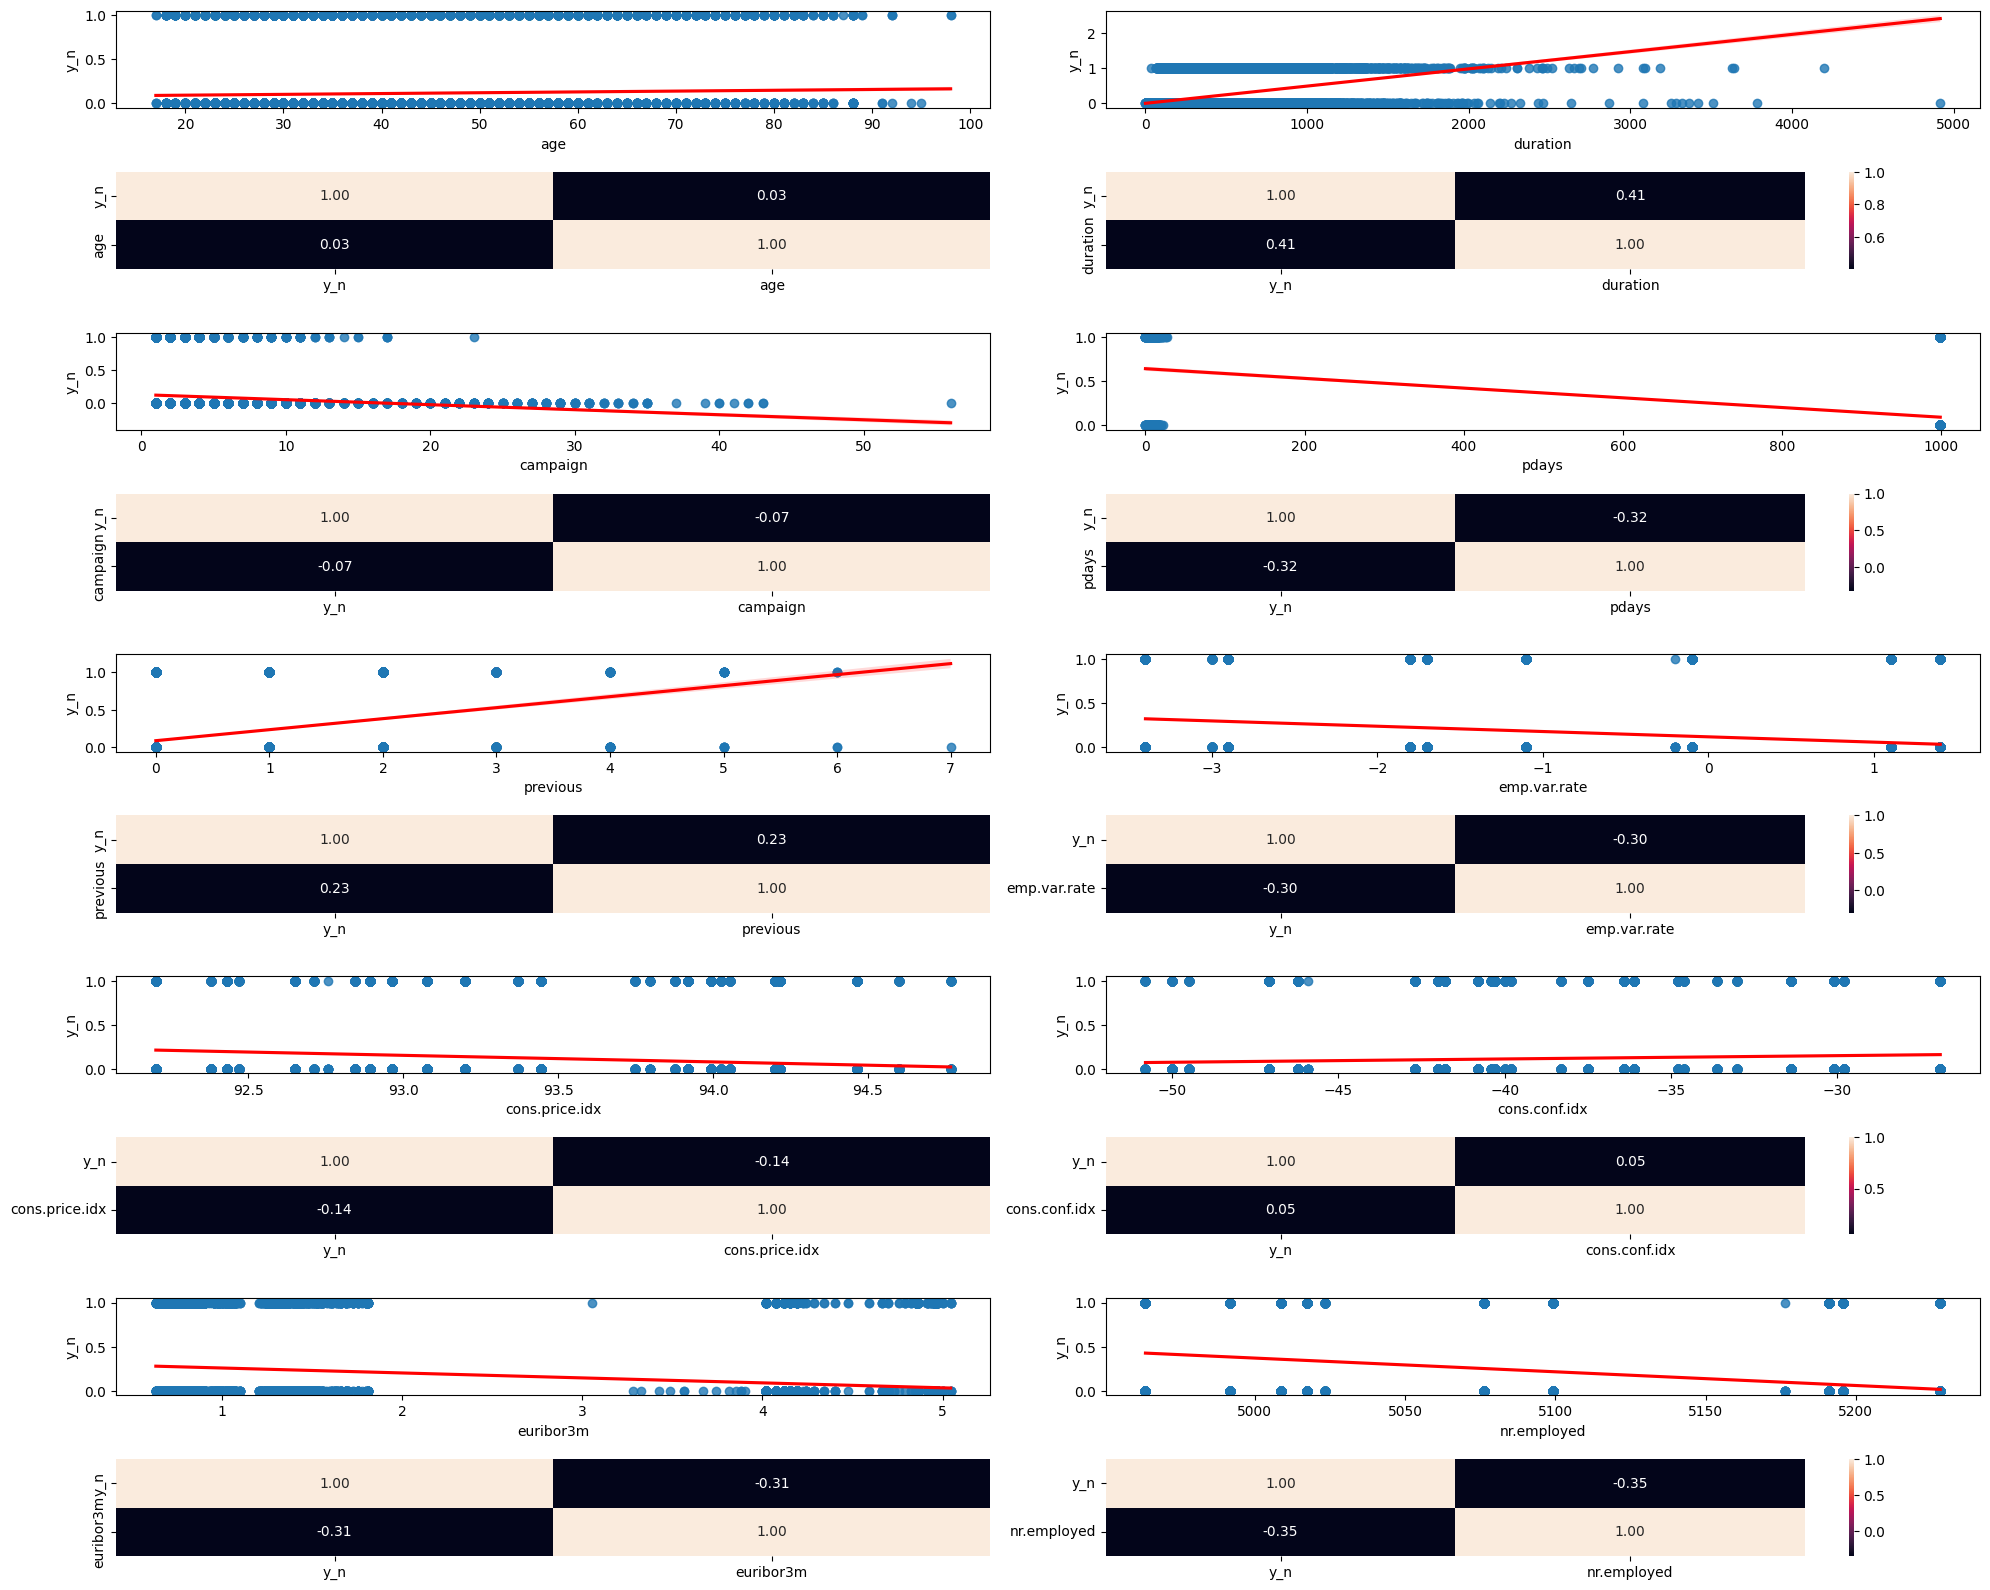

In [13]:
fig, axis = plt.subplots(10, 2, figsize=(20, 16))

sns.regplot(ax=axis[0, 0], data=df, x='age', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'age']].corr(), annot=True, fmt='.2f', ax=axis[1, 0], cbar=False)
sns.regplot(ax=axis[0, 1], data=df, x='duration', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'duration']].corr(), annot=True, fmt='.2f', ax=axis[1, 1])
sns.regplot(ax=axis[2, 0], data=df, x='campaign', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'campaign']].corr(), annot=True, fmt='.2f', ax=axis[3, 0], cbar=False)
sns.regplot(ax=axis[2, 1], data=df, x='pdays', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'pdays']].corr(), annot=True, fmt='.2f', ax=axis[3, 1])
sns.regplot(ax=axis[4, 0], data=df, x='previous', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'previous']].corr(), annot=True, fmt='.2f', ax=axis[5, 0], cbar=False)
sns.regplot(ax=axis[4, 1], data=df, x='emp.var.rate', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'emp.var.rate']].corr(), annot=True, fmt='.2f', ax=axis[5, 1])
sns.regplot(ax=axis[6, 0], data=df, x='cons.price.idx', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'cons.price.idx']].corr(), annot=True, fmt='.2f', ax=axis[7, 0], cbar=False)
sns.regplot(ax=axis[6, 1], data=df, x='cons.conf.idx', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'cons.conf.idx']].corr(), annot=True, fmt='.2f', ax=axis[7, 1])
sns.regplot(ax=axis[8, 0], data=df, x='euribor3m', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'euribor3m']].corr(), annot=True, fmt='.2f', ax=axis[9, 0], cbar=False)
sns.regplot(ax=axis[8, 1], data=df, x='nr.employed', y='y_n', line_kws={'color': 'red'})
sns.heatmap(df[['y_n', 'nr.employed']].corr(), annot=True, fmt='.2f', ax=axis[9, 1])

plt.tight_layout()

> ## Observaciones
>
> - Hay una relación directa entre el target y la duración del contacto previo, logicamente cuanto más tiempo duró el ultimo contacto previo, más clientes contrataron.
> - Existe una relación directa negativa entre el target y 'pdays', cuantos más días pasarón desde la ultima campaña hasta que fue contactado, menos clientes contrataron.
> - Existe una relacion directa negativa entre el target y 'emp.var.rate', si la tasa de variacion de empleo crece, bajan los clientes contratados (Dato sospechoso)
> - Existe una relacion directa negativa entre el target y 'euribor3m', logicamente si el euribor baja, suben los clientes contratados.
> - Existe una relacion directa negativa entre el target y 'nr.emplyed', conforme hemos visto antes con la tasa de varaicion de empleo, si el numero de empleados crece, bajan los clientes contratados (Dato sospechoso)

### Análisis de Variables Multivariante (categórico-categórico)
    y - (job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome)

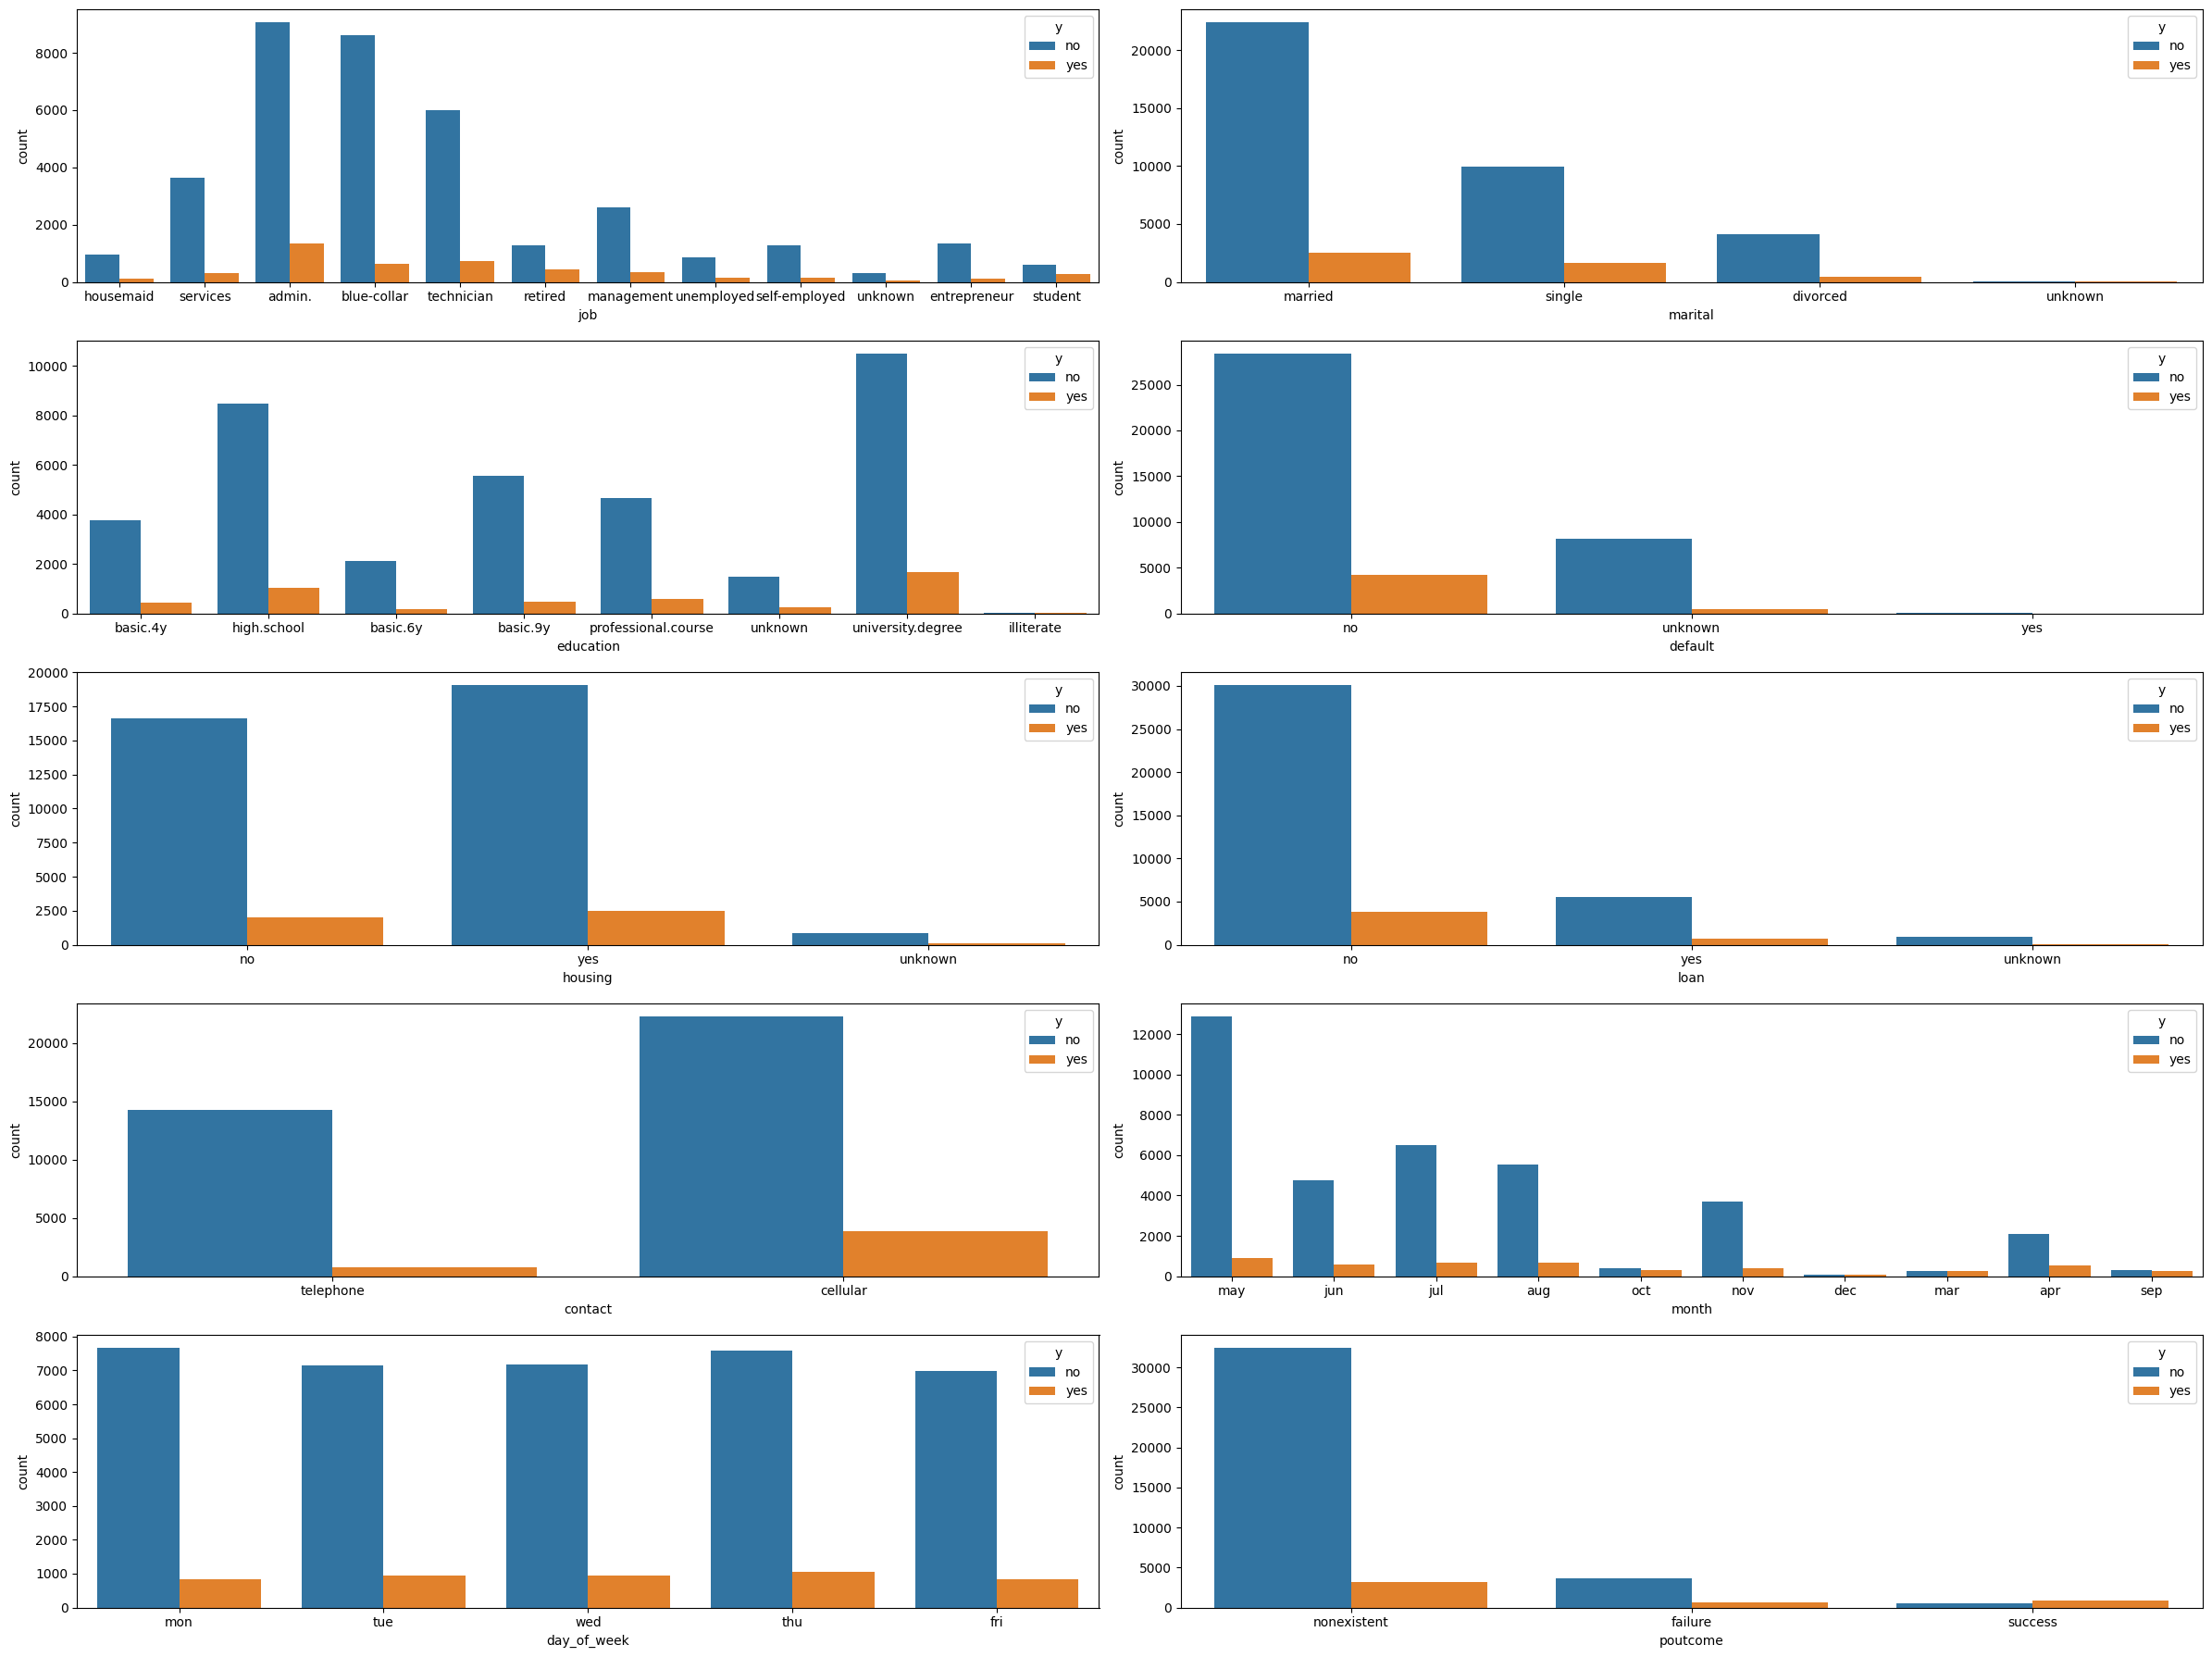

In [14]:
fig, axis = plt.subplots(5, 2, figsize=(24, 18))

sns.countplot(ax=axis[0,0], data=df, x='job', hue='y')
sns.countplot(ax=axis[0,1], data=df, x='marital', hue='y')
sns.countplot(ax=axis[1,0], data=df, x='education', hue='y')
sns.countplot(ax=axis[1,1], data=df, x='default', hue='y')
sns.countplot(ax=axis[2,0], data=df, x='housing', hue='y')
sns.countplot(ax=axis[2,1], data=df, x='loan', hue='y')
sns.countplot(ax=axis[3,0], data=df, x='contact', hue='y')
sns.countplot(ax=axis[3,1], data=df, x='month', hue='y')
sns.countplot(ax=axis[4,0], data=df, x='day_of_week', hue='y')
sns.countplot(ax=axis[4,1], data=df, x='poutcome', hue='y')

plt.tight_layout()

> ## Observaciones:
>
> - Respecto al 'poutcome', los clientes que resultaron exitosos de la campaña de marketing anterior es un poco más probable que contraten un deposito a largo plazo


#### Combinaciones del target con varias predictoras

<Axes: xlabel='marital', ylabel='y_n'>

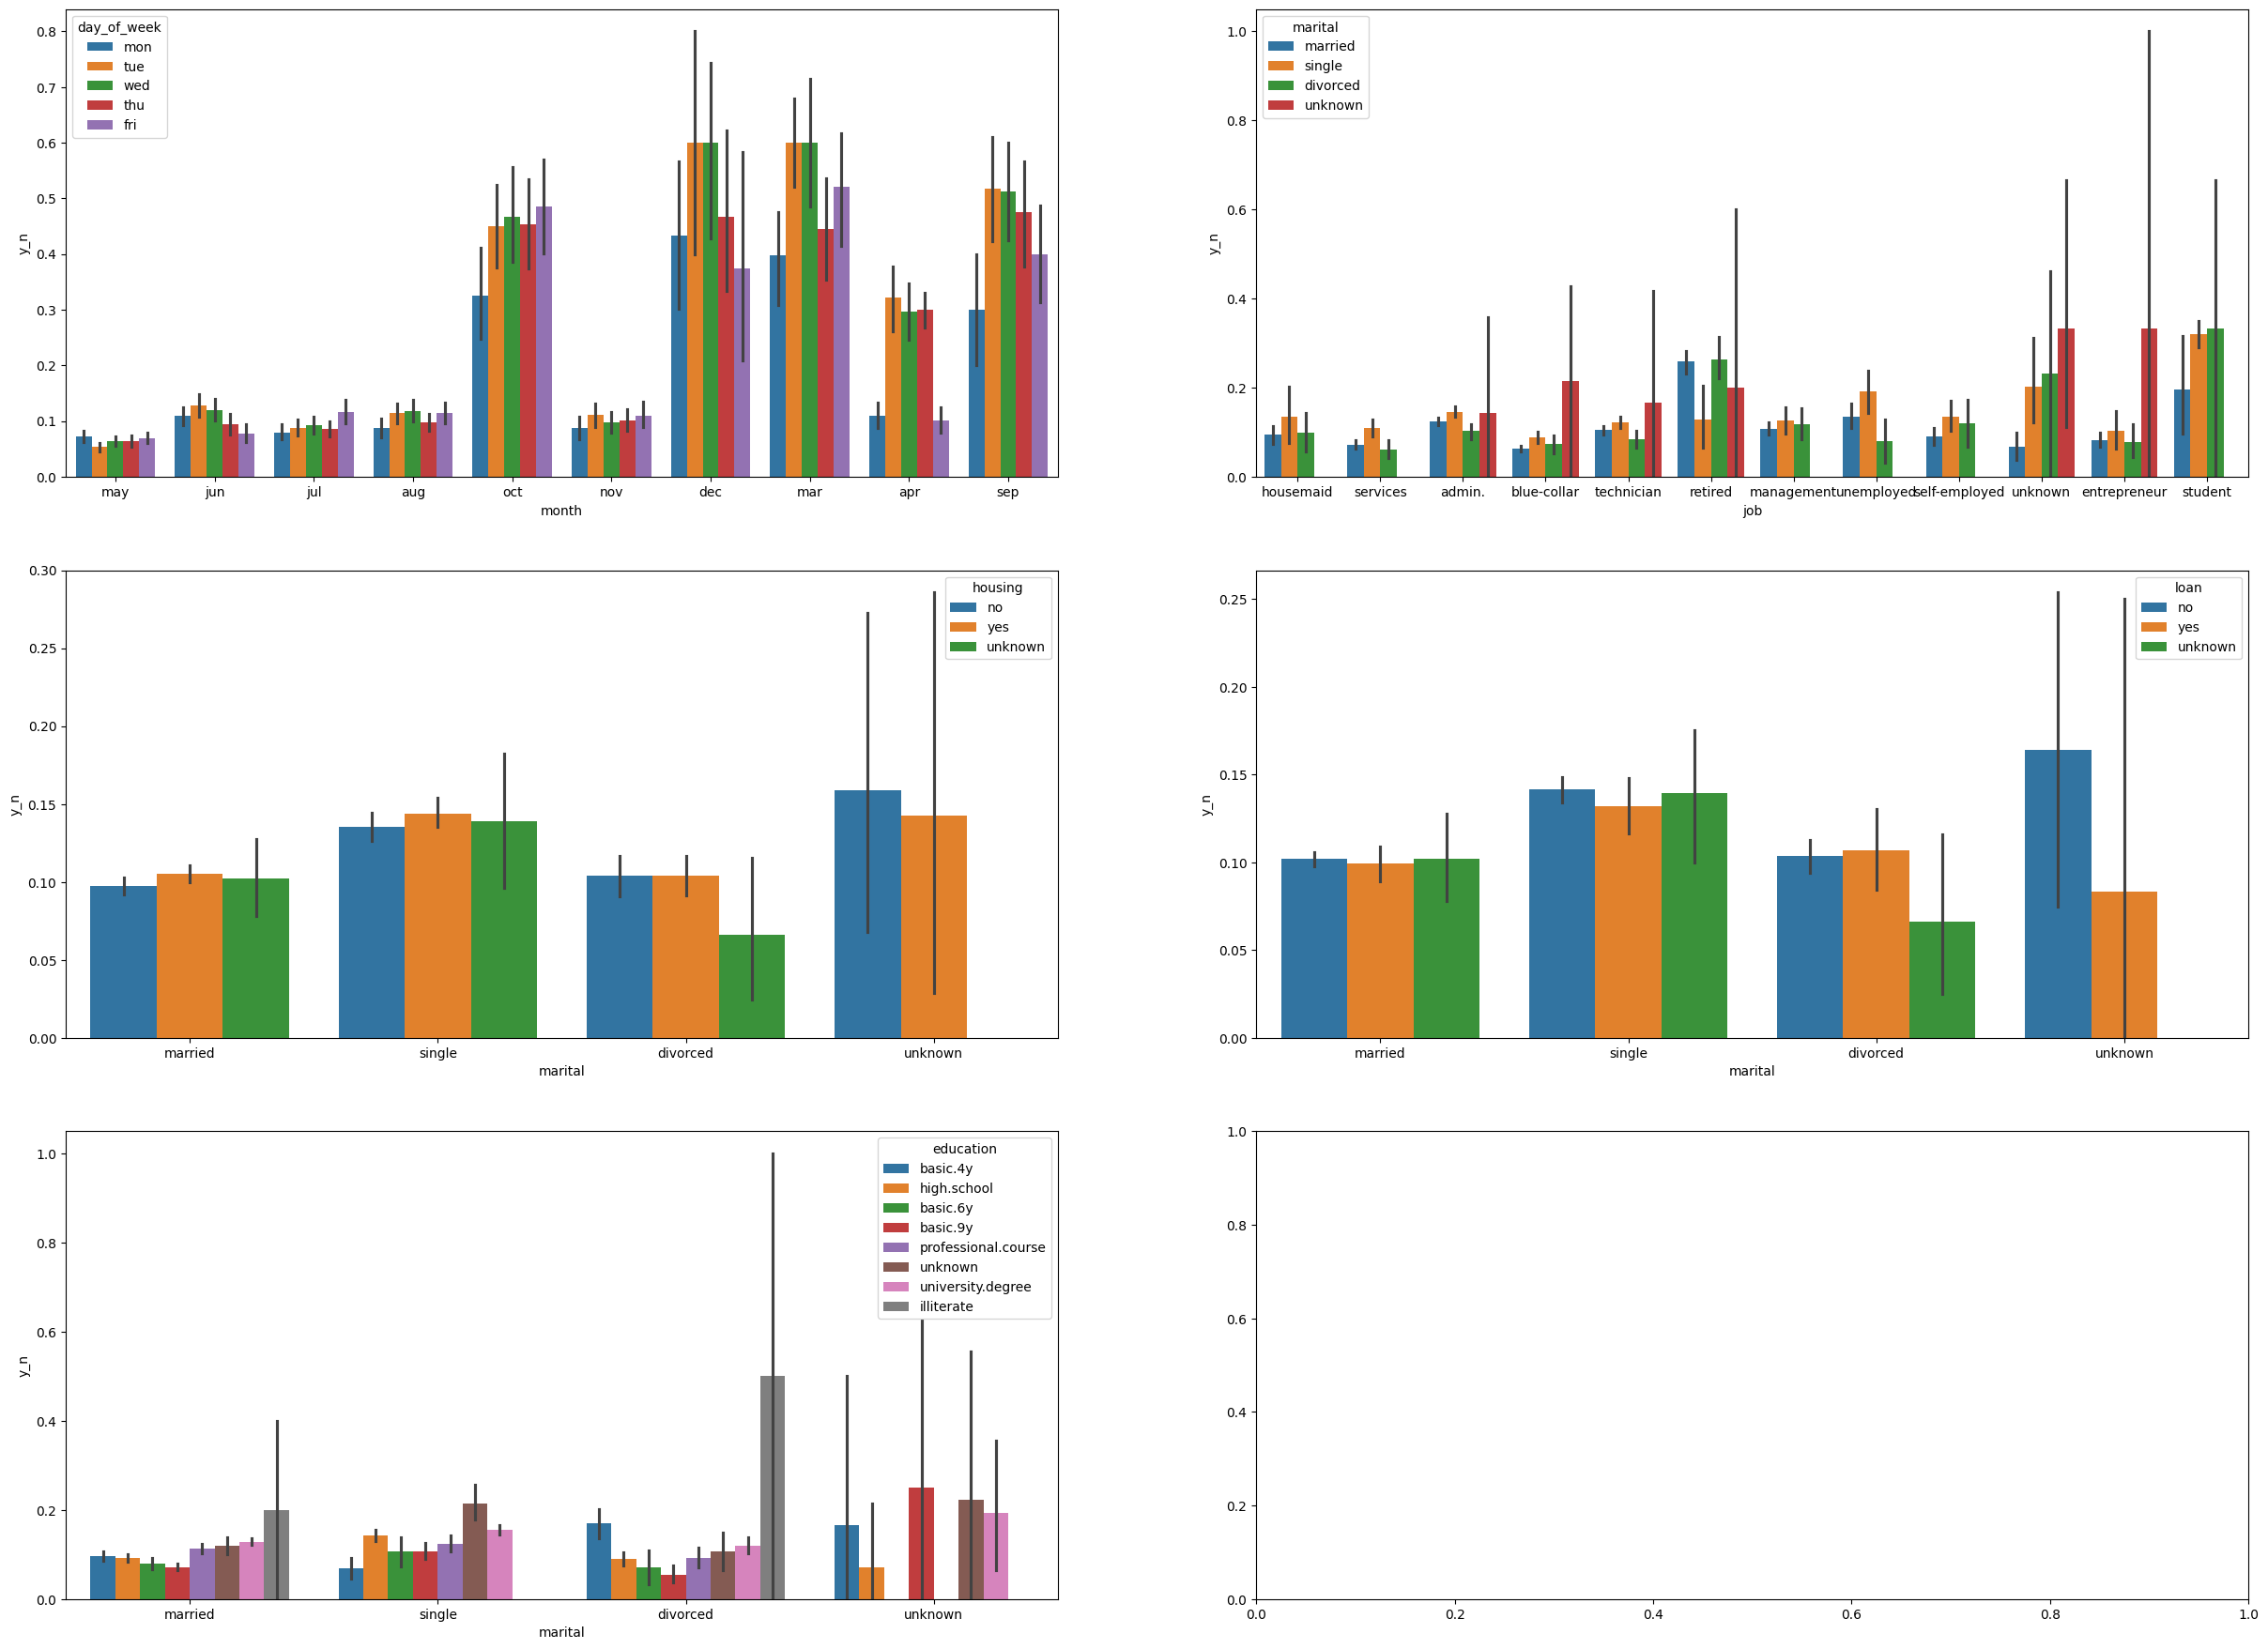

In [15]:
fig, axis = plt.subplots(3, 2, figsize=(30, 22))

sns.barplot(ax=axis[0, 0], data=df, x='month', y='y_n', hue='day_of_week')
sns.barplot(ax=axis[0, 1], data=df, x='job', y='y_n', hue='marital')
sns.barplot(ax=axis[1, 0], data=df, x='marital', y='y_n', hue='housing')
sns.barplot(ax=axis[1, 1], data=df, x='marital', y='y_n', hue='loan')
sns.barplot(ax=axis[2, 0], data=df, x='marital', y='y_n', hue='education')

> ## Observaciones
>
> - Los meses que hay diferencias significativas de clientes contratados por dia son: octubre(lunes flojo), diciembre(lunes, jueves, viernes flojos), marzo(lunes, jueves flojos), abril(lunes, viernes flojos), septiembre(lunes flojo)
> - La mayoría de los clientes contratados divorciados no tienen estudios

#### Análisis de correlaciones categórico-numérico

In [ ]:
# Creo columnas numéricas para las variables categóricas
df['job_n'] = pd.factorize(df['job'])[0]
df['marital_n'] = pd.factorize(df['marital'])[0]
df['education_n'] = pd.factorize(df['education'])[0]
df['default_n'] = pd.factorize(df['default'])[0]
df['housing_n'] = pd.factorize(df['housing'])[0]
df['loan_n'] = pd.factorize(df['loan'])[0]
df['contact_n'] = pd.factorize(df['contact'])[0]
df['month_n'] = pd.factorize(df['month'])[0]
df['day_of_week_n'] = pd.factorize(df['day_of_week'])[0]
df['poutcome_n'] = pd.factorize(df['poutcome'])[0]

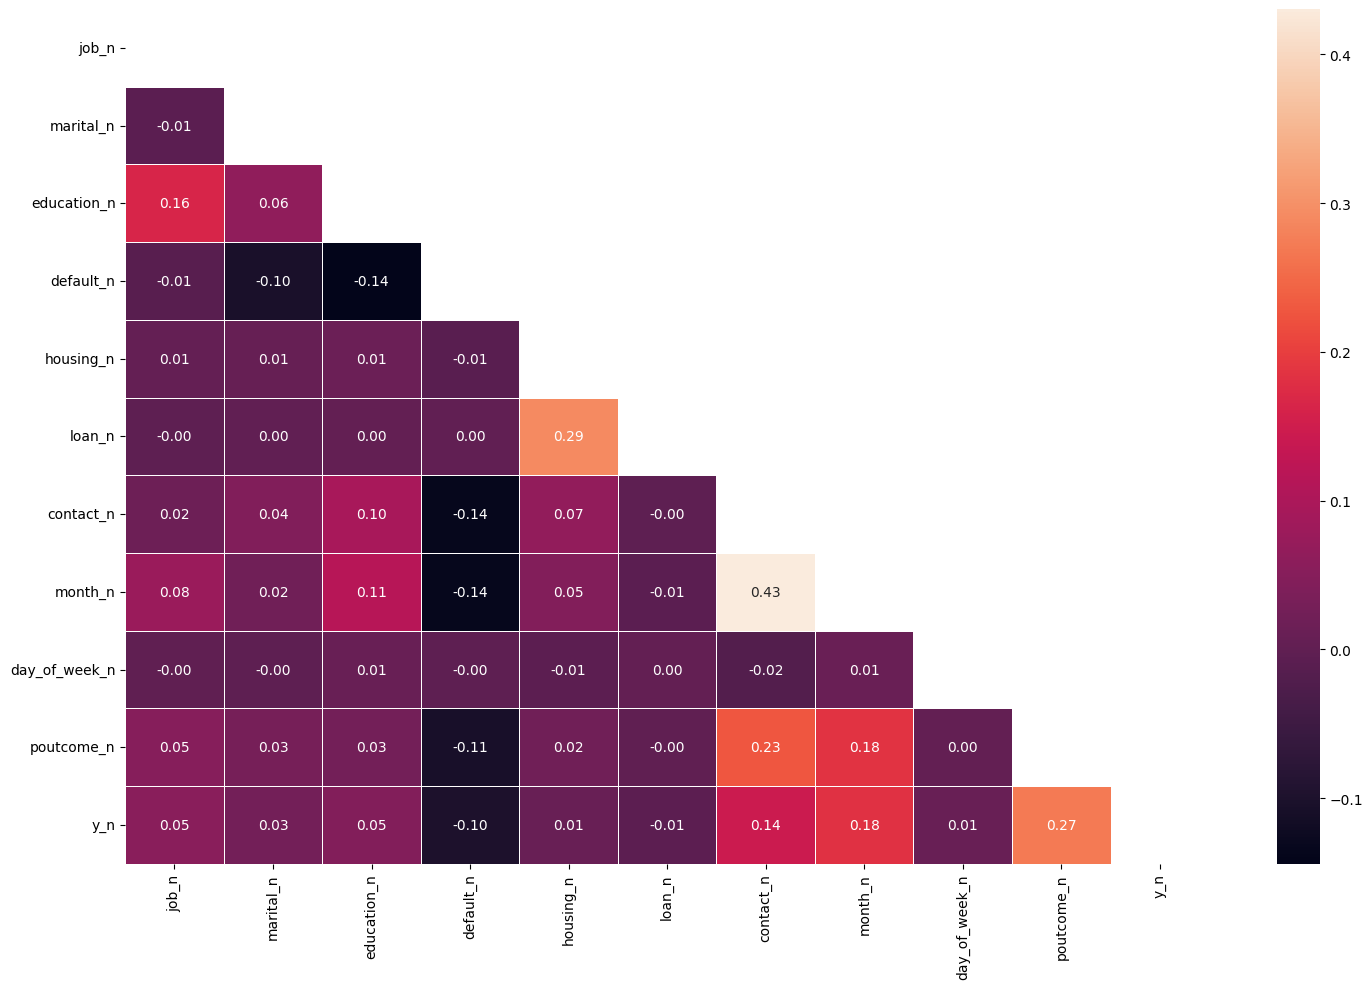

In [18]:
corr = df[['job_n', 'marital_n', 'education_n', 'default_n', 'housing_n', 'loan_n', 'contact_n', 'month_n', 'day_of_week_n', 'poutcome_n', 'y_n']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15,10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()

> ## Observaciones:
>
> - Como hemos visto antes, hay una pequeña relación directa con el target y el 'poutcome' (la unica variable categóica que tiene algo de relación con el target),  si aumentan los clientes exitosos de la campaña de marketing anterior aumenta los cliente que contraten un deposito a largo plazo
> - Exite una pequeña relación directa entre `loan` y `housing`, los clientes que tienen un préstamo personal también tienen un préstamo de vivienda
> - Existe una relacion directa entre `contact` y `month`, pero no resulta significativa.

<Axes: xlabel='month_n', ylabel='contact_n'>

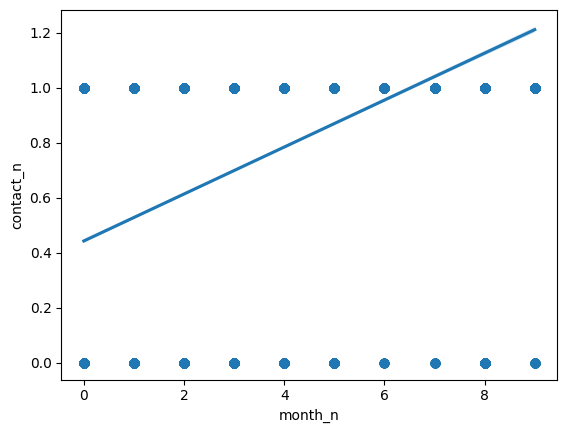

In [19]:
sns.regplot(data=df, x="month_n", y="contact_n")

#### Análisis de correlaciones numérico-numérico

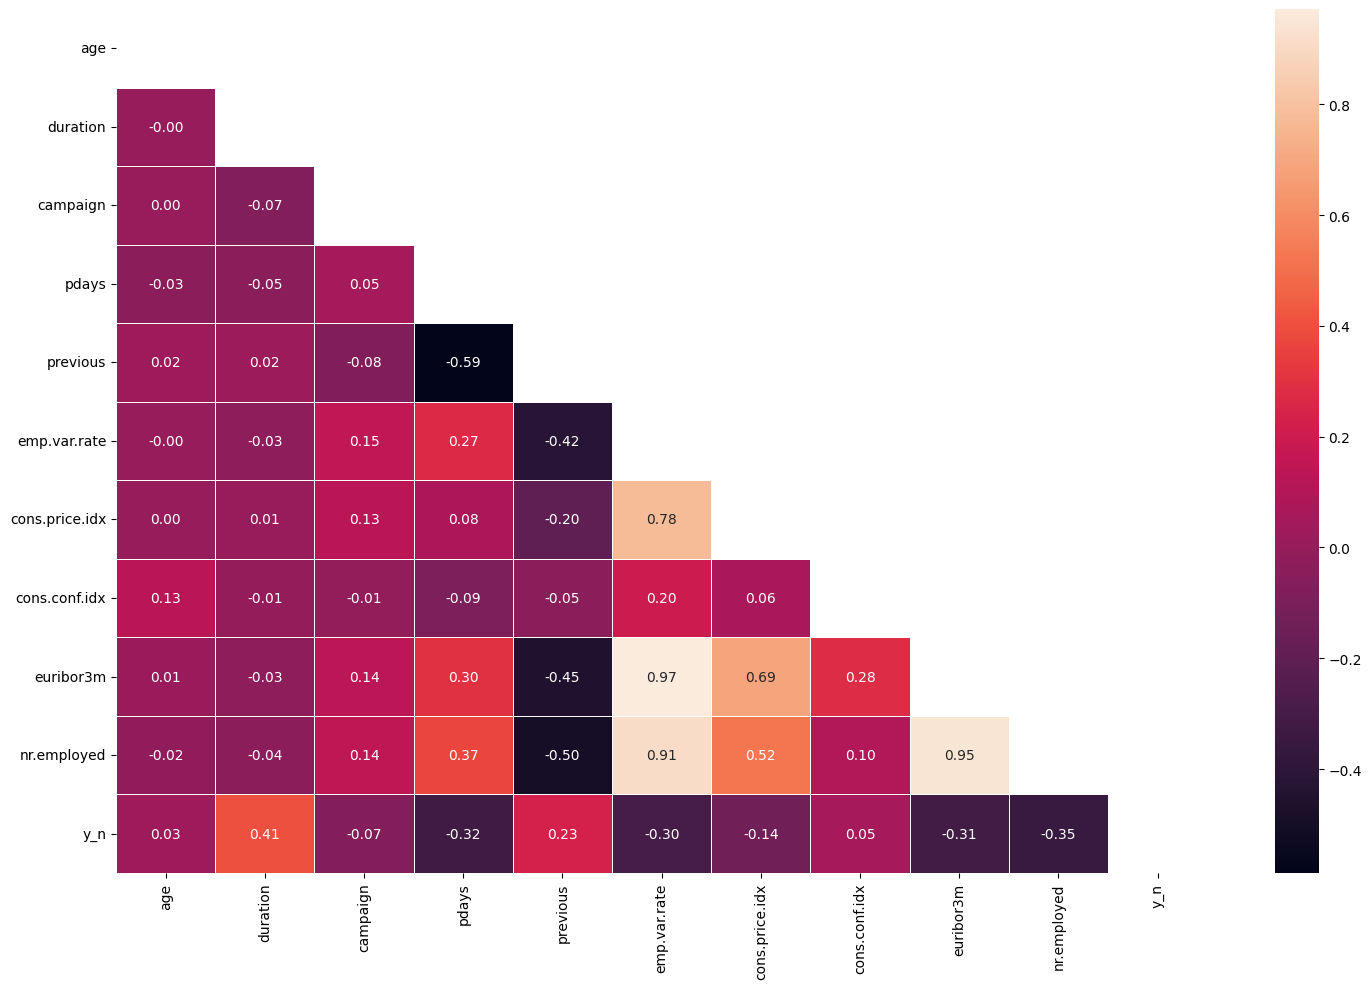

In [20]:
var_numericas = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_n']
corr = df[var_numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()


> ## Observaciones:
> - Hay una fuerte relación directa entre `pdays` y `previous`
> - El resto de correlaciones se mantienen con respecto a lo visto anteriormente.

### Ingeniería de características

#### Análisis de outliers

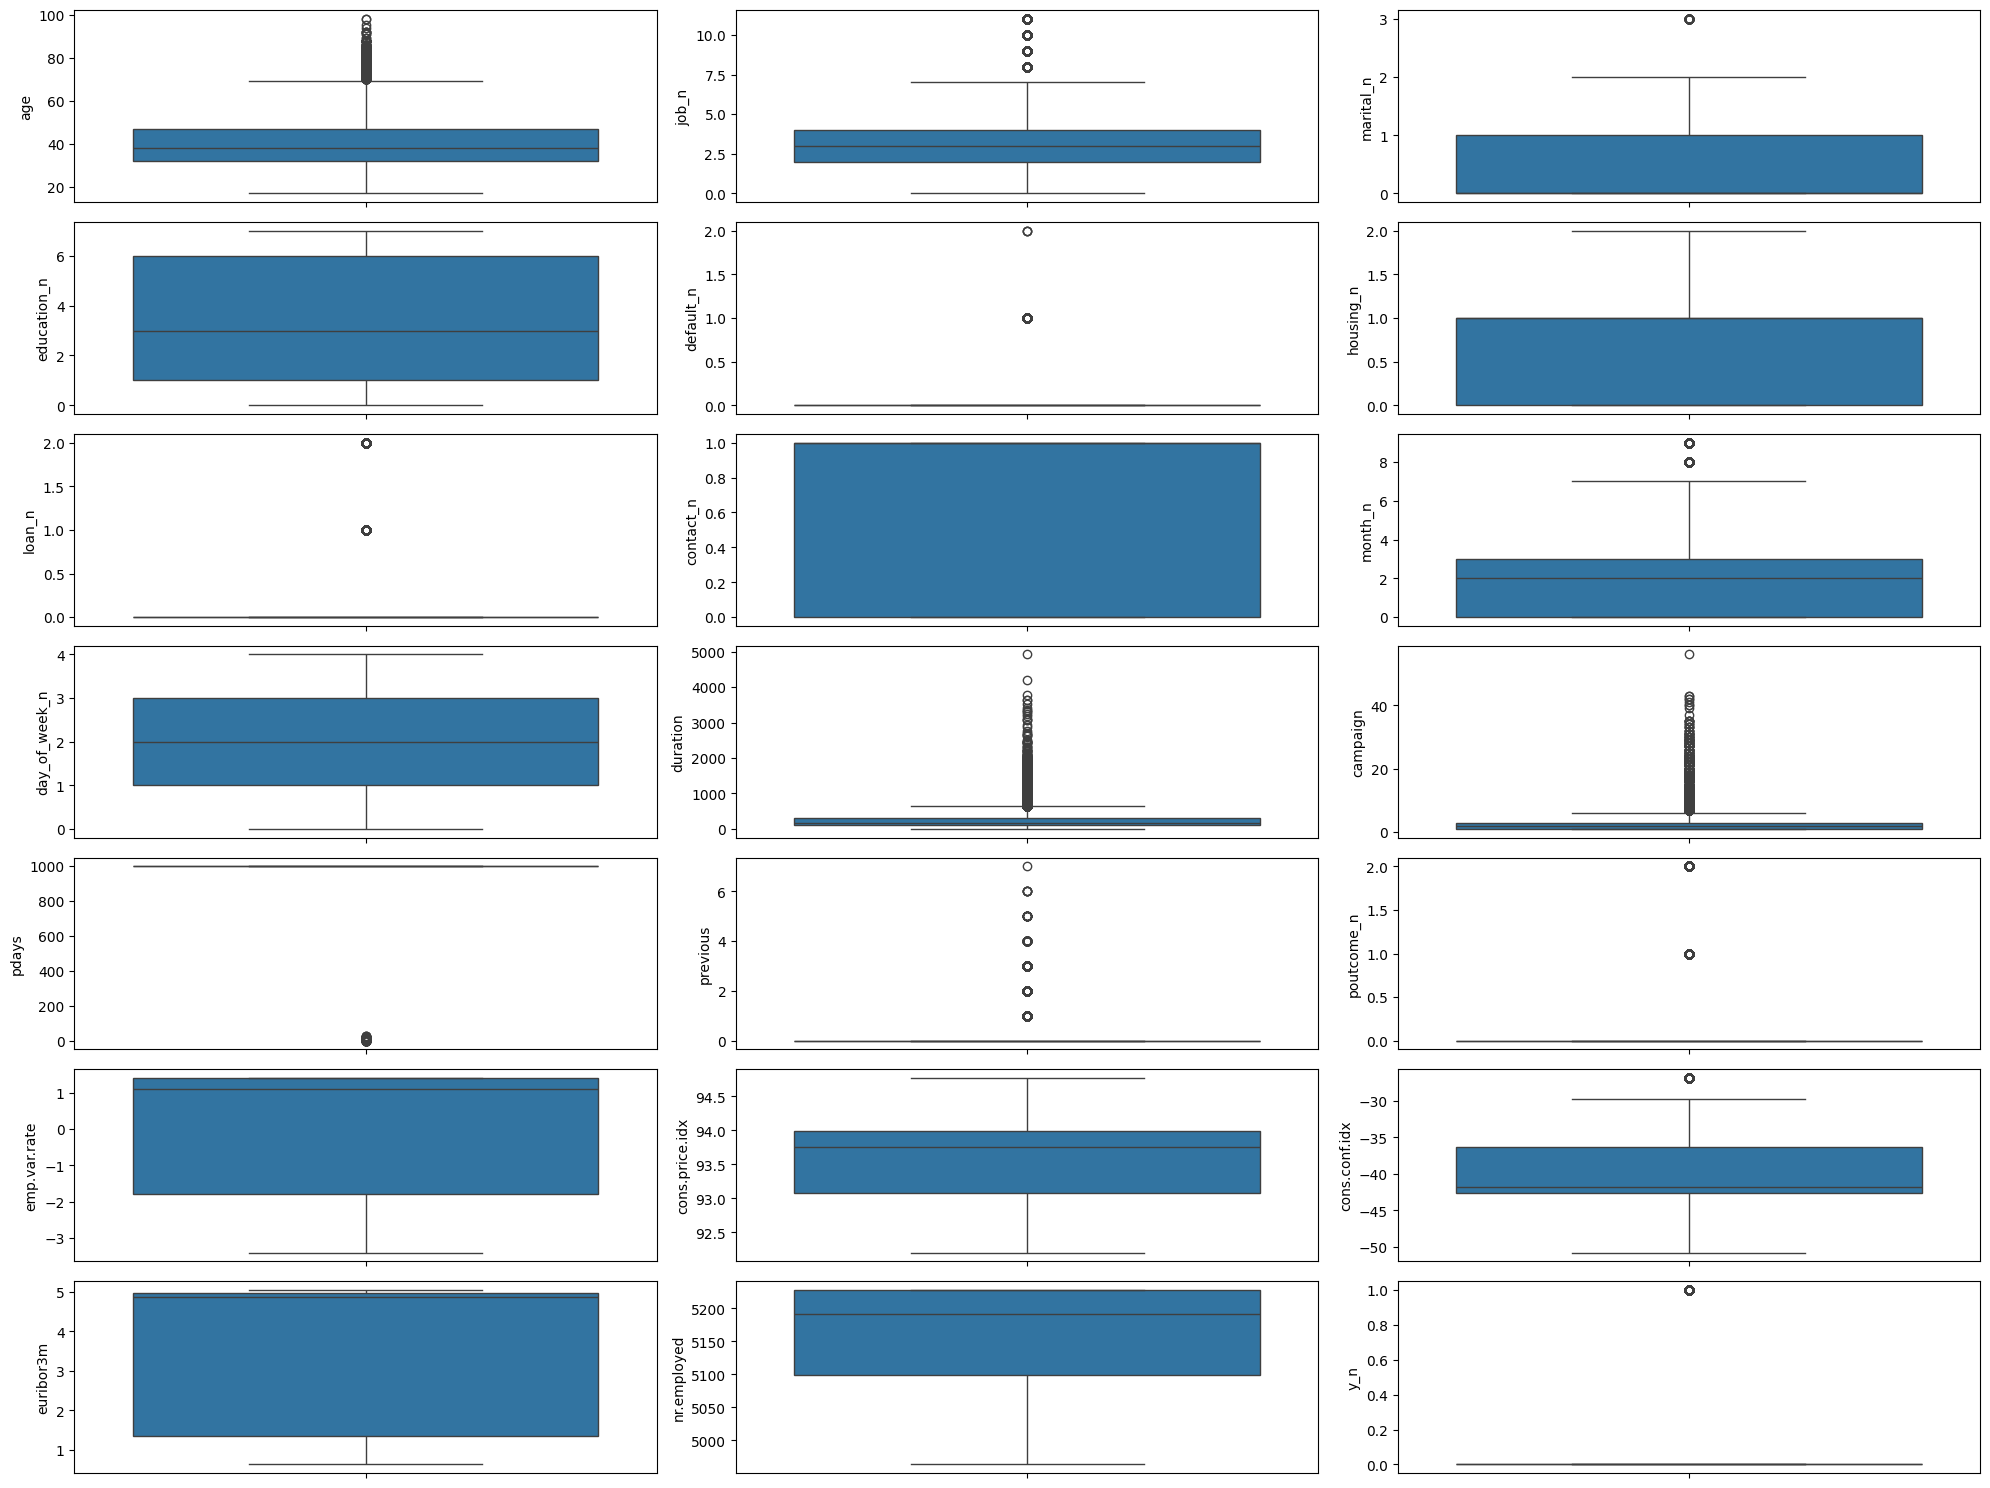

In [21]:
fig, axis = plt.subplots(7, 3, figsize=(20, 15))

sns.boxplot(ax=axis[0, 0], data=df, y="age")
sns.boxplot(ax=axis[0, 1], data=df, y="job_n")
sns.boxplot(ax=axis[0, 2], data=df, y="marital_n")
sns.boxplot(ax=axis[1, 0], data=df, y="education_n")
sns.boxplot(ax=axis[1, 1], data=df, y="default_n")
sns.boxplot(ax=axis[1, 2], data=df, y="housing_n")
sns.boxplot(ax=axis[2, 0], data=df, y="loan_n")
sns.boxplot(ax=axis[2, 1], data=df, y="contact_n")
sns.boxplot(ax=axis[2, 2], data=df, y="month_n")
sns.boxplot(ax=axis[3, 0], data=df, y="day_of_week_n")
sns.boxplot(ax=axis[3, 1], data=df, y="duration")
sns.boxplot(ax=axis[3, 2], data=df, y="campaign")
sns.boxplot(ax=axis[4, 0], data=df, y="pdays")
sns.boxplot(ax=axis[4, 1], data=df, y="previous")
sns.boxplot(ax=axis[4, 2], data=df, y="poutcome_n")
sns.boxplot(ax=axis[5, 0], data=df, y="emp.var.rate")
sns.boxplot(ax=axis[5, 1], data=df, y="cons.price.idx")
sns.boxplot(ax=axis[5, 2], data=df, y="cons.conf.idx")
sns.boxplot(ax=axis[6, 0], data=df, y="euribor3m")
sns.boxplot(ax=axis[6, 1], data=df, y="nr.employed")
sns.boxplot(ax=axis[6, 2], data=df, y="y_n")

plt.tight_layout()

> ## Observaciones:
> - Podemos determinar fácilmente que las variables afectadas por outliers son: age, job_n, marital_n, default_n, loan_n, month_n, duration, campaign, pdays, previous, poutcome_n, cons.conf.idx, y_n
> - De momento vamos a mantener todos los outliers.

#### Análisis de valores faltantes

In [22]:
df.isnull().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_n               0
job_n             0
marital_n         0
education_n       0
default_n         0
housing_n         0
loan_n            0
contact_n         0
month_n           0
day_of_week_n     0
poutcome_n        0
dtype: int64

> ## Observaciones:
> - Según el método `isnull` no hay valores nulos, pero conforme hemos visto antes si que hay pero están identidicados como unknown 

#### Inferencia de nuevas características

In [23]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,0,0,0,0,0,0,0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,0,1,1,0,0,0,0,0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,0,1,0,1,0,0,0,0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,2,0,2,0,0,0,0,0,0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,0,1,0,0,1,0,0,0,0


> ## Observaciones 
> 
> - No encontramos relación para crear una variable a partir de la fusion de varias

### Split (Segundo Enfoque)

In [ ]:
# Dividimos el conjunto de datos en muestras de train y test
X = df.drop(['y', 'y_n'], axis=1)
y= df['y']

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


12556     no
35451     no
30592     no
17914     no
3315      no
        ... 
6265      no
11284     no
38158    yes
860       no
15795     no
Name: y, Length: 32950, dtype: object

### Scaling - Escalado Mínimo-Máximo (variables numércias)

In [ ]:
num_variables = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
                 'job_n', 'marital_n', 'education_n', 'default_n', 'housing_n', 'loan_n', 'contact_n', 'month_n', 'day_of_week_n', 'poutcome_n']
min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X_train[num_variables])

X_train_scal = min_max_scaler.transform(X_train[num_variables])
X_train_scal = pd.DataFrame(X_train_scal, index = X_train.index, columns = num_variables)

X_test_scal = min_max_scaler.transform(X_test[num_variables])
X_train_scal = pd.DataFrame(X_test_scal, index = X_test.index, columns = num_variables)

X_train_scal.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_n,marital_n,education_n,default_n,housing_n,loan_n,contact_n,month_n,day_of_week_n,poutcome_n
12556,0.283951,0.019113,0.018182,1.0,0.000000,1.000000,0.669135,0.338912,0.980730,1.000000,0.272727,0.000000,0.428571,0.5,0.5,0.0,0.0,0.222222,0.00,0.0
35451,0.172840,0.023587,0.054545,1.0,0.000000,0.333333,0.269680,0.192469,0.138291,0.512287,0.181818,0.000000,0.857143,0.0,0.0,0.0,1.0,0.000000,0.00,0.0
30592,0.518519,0.002643,0.090909,1.0,0.142857,0.333333,0.269680,0.192469,0.163228,0.512287,0.454545,0.000000,0.000000,0.0,0.0,0.0,1.0,0.000000,0.00,0.5
17914,0.320988,0.019113,0.072727,1.0,0.000000,1.000000,0.669135,0.338912,0.980957,1.000000,0.000000,0.666667,0.428571,0.0,0.5,0.0,1.0,0.222222,0.25,0.0
3315,0.271605,0.069947,0.018182,1.0,0.000000,0.937500,0.698753,0.602510,0.958059,0.859735,0.181818,0.333333,0.142857,0.5,0.0,0.0,0.0,0.000000,0.75,0.0


In [38]:
# Guardamos  escaler utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/logistic-regression-min_max_scaler.pkl', 'wb') as file:
    pickle.dump(min_max_scaler, file)

> ## Conclusiones
>
> EDA terminado, ya tenemos el conjunto de datos de entrenamiento y pruba para empezar a construir el modelo.
> - `X_train_scal`, `X_test_scal` ,`y_train` , `y_test`


## Paso 3: Construimos un modelo de regresión logística

### Inicialización y entrenamiento del modelo